In [55]:
import xarray as xr
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import itertools as it
from glob import glob
from netCDF4 import Dataset
from matplotlib.cm import get_cmap
import gc

prefix = '20250313'
path_root = f'/gpfs/wolf2/cades/cli185/proj-shared/zdr/ERW/output/{prefix}_conus_ICB20TRCNPRDCTCBC_erw_pft1/'
path_out = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'transient')

zsoi = np.array([0.0071, 0.0279, 0.0623, 0.1189, 0.2122, 0.3661, 0.6198, 1.0380, 1.7276, 2.8646])
zisoi = np.array([0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 1.3828, 2.2961, 3.8019])
dzsoi = np.array([0.0175, 0.0276, 0.0455, 0.0750, 0.1236, 0.2038, 0.3360, 0.5539, 0.9133, 1.5058])

# minerals_name = ['Wollastonite_CaSiO3', 'Forsterite_Mg2SiO4', 'Albite_NaAlSi3O8', 
#                 'Anorthite_CaAl2Si2O8', 'Epidote_Ca2FeAl2(SiO4)3(OH)', 'Calcite_CaCO3',
#                 'Labradorite_Ca0.6Na0.4Al1.6Si2.4O8', 'Augite_Ca0.9Mg0.9Na0.1Al0.4Fe0.2Si1.9O6',
#                 'Kfeldspar_KAlSi3O8', 'Enstatite_MgSiO3']
# normal alkali basalt (fast)
pct_basalt = np.array([0, 12, 0, 0, 0, 0, 43, 21, 6, 0])
# normal tholeiitic basalt (slow)
# pct_basalt = np.array([0, 0, 0, 0, 0, 0, 45, 34, 5, 3])

cation_names = ['Ca2+', 'Mg2+', 'Na+', 'K+', 'Al3+']
cation_masses = [40, 24, 23, 39, 27]
cation_valences = [2, 2, 1, 1, 3]

start_year = 2000
end_year = 2100

# 1. Spatial map of r_sequestration, this run only

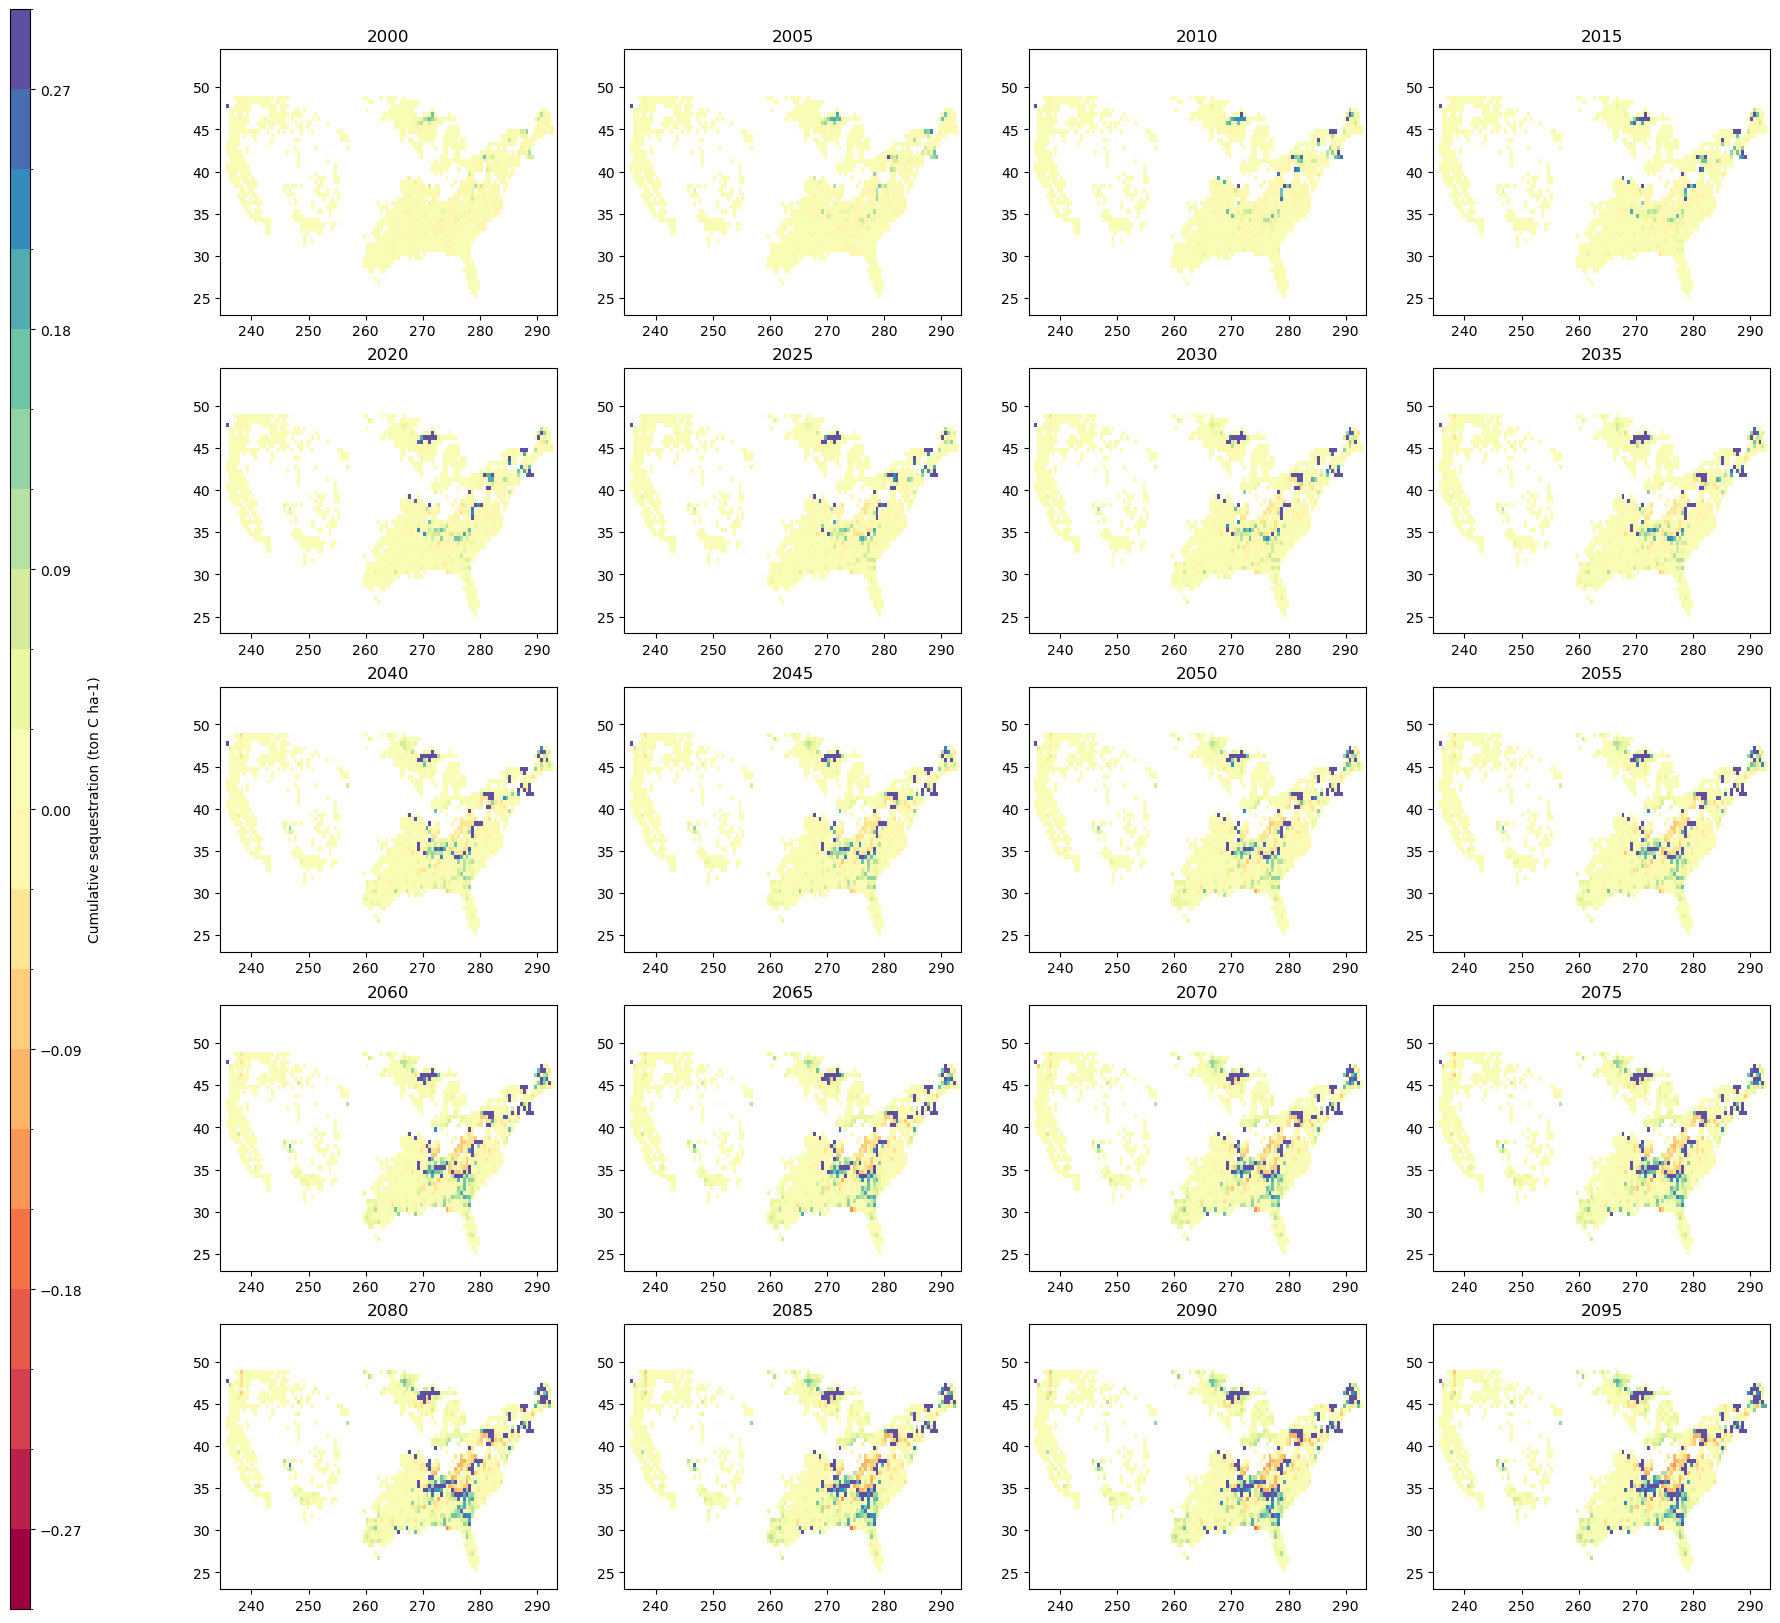

In [24]:
fig, axes = plt.subplots(5, 4, figsize = [20, 20])

for j, year in enumerate(range(start_year, end_year, 5)):

    hr = xr.open_dataset(
        os.path.join(path_root, 'run', 
                    f'{prefix}_conus_ICB20TRCNPRDCTCBC_erw_pft1.elm.h0.{year}-01-01-00000.nc')
    )

    norm = BoundaryNorm(boundaries = np.linspace(-0.3, 0.3, 21), ncolors=256)

    ax = axes.flat[j]

    # gC m-2 s-1 => ton C ha-1 s-1
    new_data = hr['r_sequestration'][0, :].values * 1e-6 * 1e4 * 86400 * 365
    new_data = new_data

    if year == start_year:
        accumulated = new_data
    else:
        accumulated = accumulated + new_data

    cf = ax.pcolormesh(hr['lon'], hr['lat'], accumulated, cmap = 'Spectral', norm = norm)

    # note: 1 kg/m2 = 10 ton/ha
    ax.set_title(year)

    hr.close()

cax = fig.add_axes([0.02, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, label = 'Cumulative sequestration (ton C ha-1)')
plt.savefig(os.path.join(path_out, f'r_sequestration_{id}.png'), dpi = 600., 
            bbox_inches = 'tight')
#plt.close(fig)

# 2. Spatial map of soil pH change

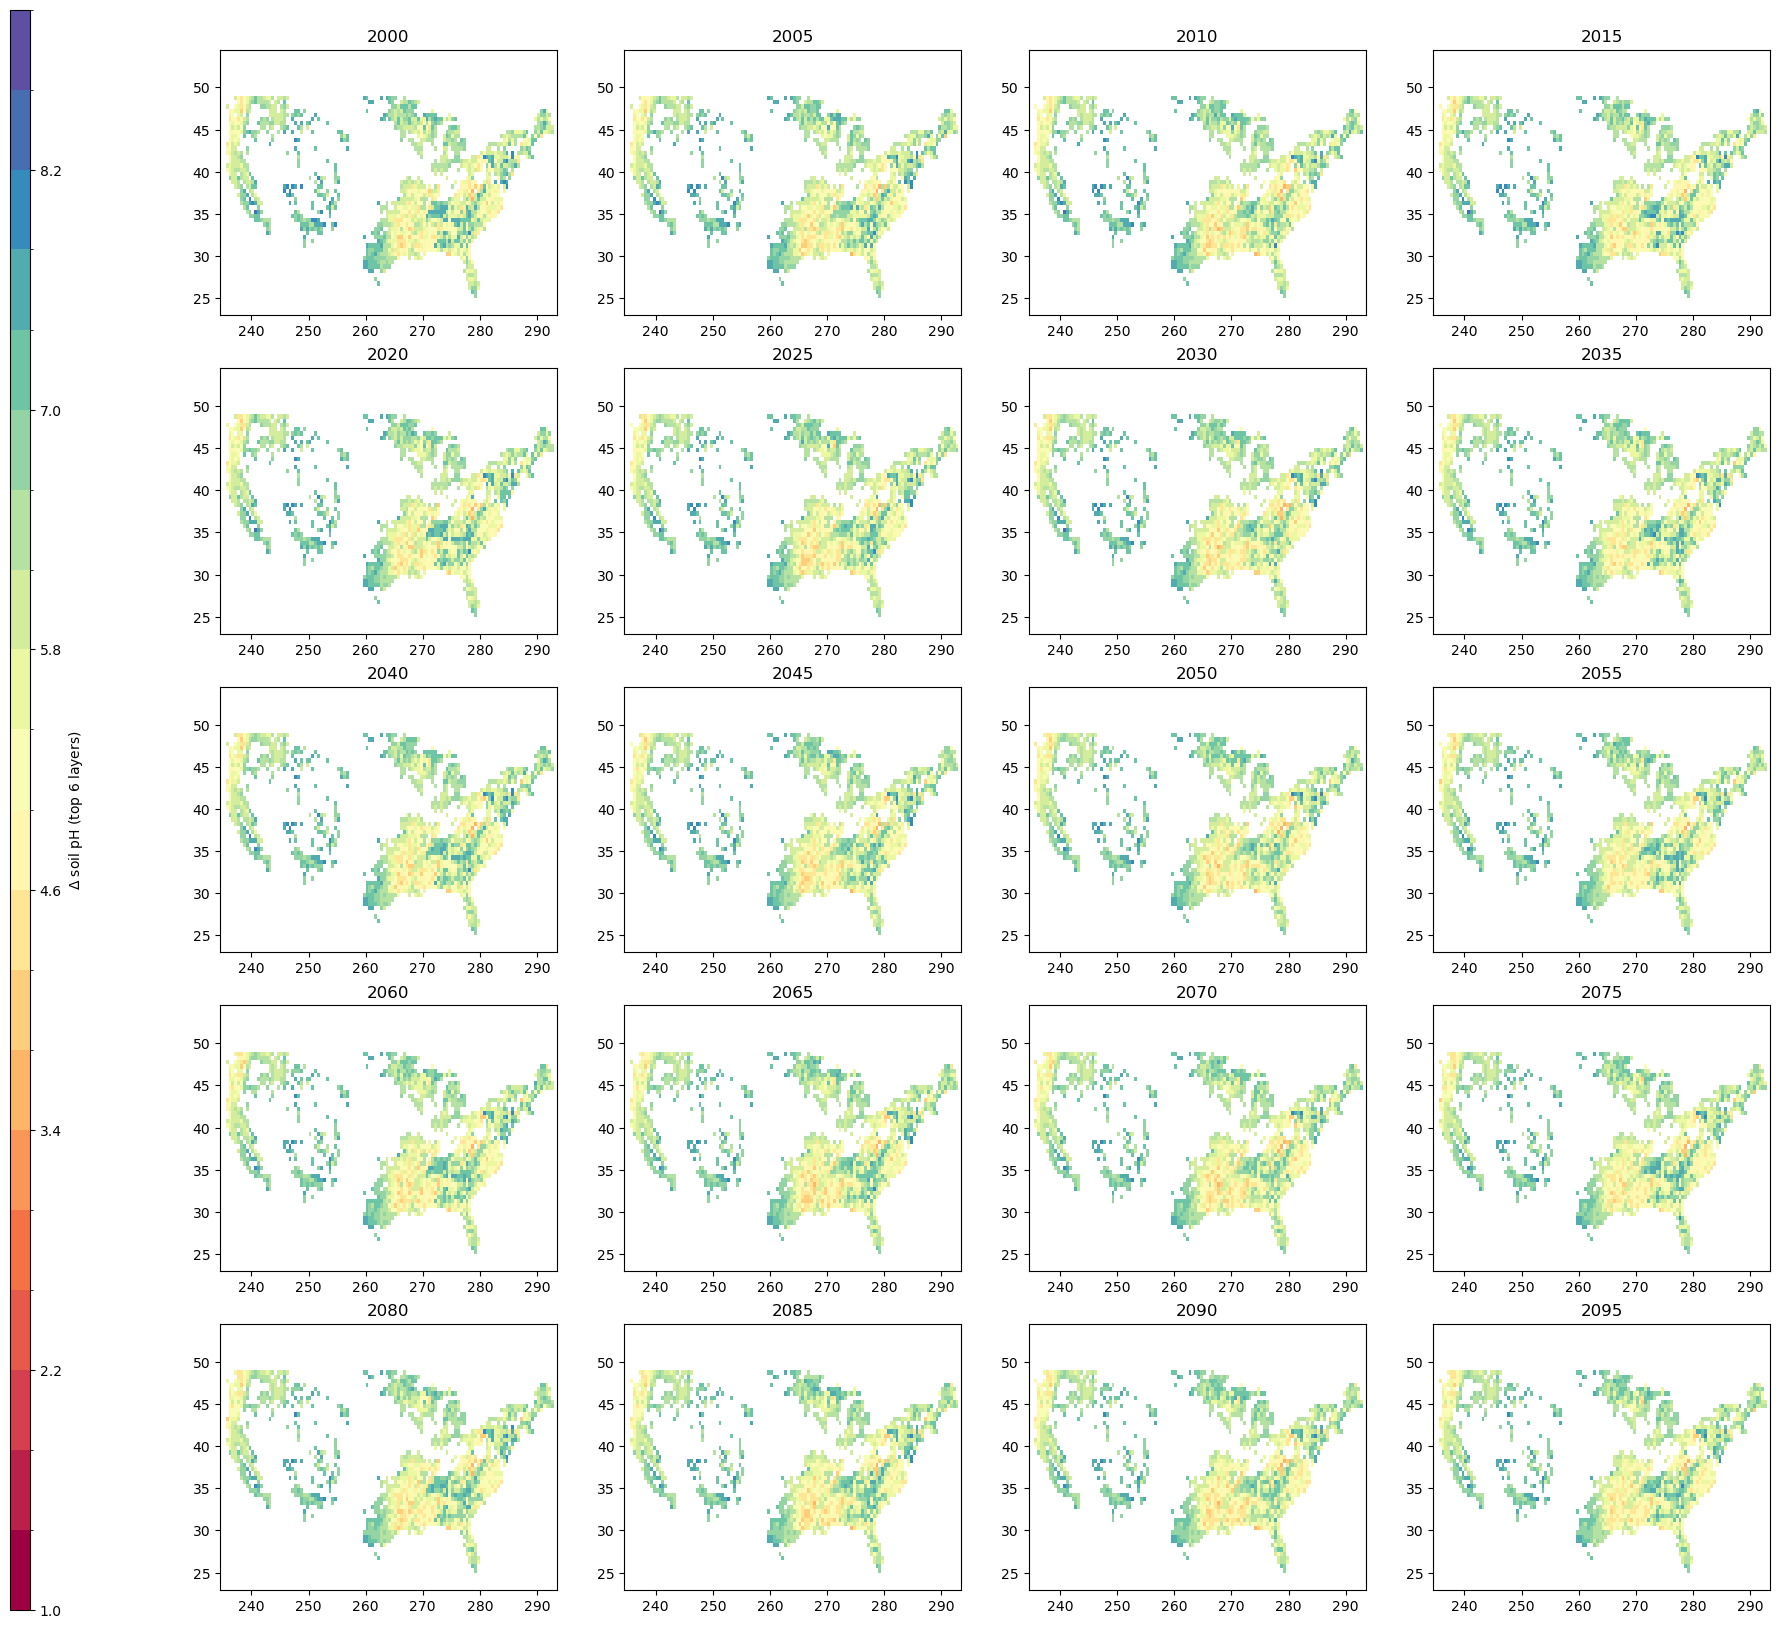

In [36]:
fig, axes = plt.subplots(5, 4, figsize = [20, 20])

for i, year in enumerate(range(start_year, end_year, 5)):

    hr = xr.open_dataset(
        os.path.join(path_root, 'run',
                    f'{prefix}_conus_ICB20TRCNPRDCTCBC_erw_pft1.elm.h0.{year}-01-01-00000.nc')
    )

    norm = BoundaryNorm(boundaries = np.linspace(1, 9, 21), ncolors=256)

    ax = axes.flat[i]

    new_data = np.sum(hr['soil_pH'][0, :6, :].values * zsoi[:6].reshape(-1,1,1), 
                      axis = 0) / np.sum(zsoi[:6])

    cf = ax.pcolormesh(
        hr['lon'], hr['lat'], new_data, 
        cmap = 'Spectral', norm = norm
    )

    ax.set_title(year)

    hr.close()

cax = fig.add_axes([0.02, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, label = 'Soil pH (top 6 layers)')
plt.savefig(os.path.join(path_out, f'soil_pH_{year}.png'), dpi = 600., 
            bbox_inches = 'tight')
#plt.close(fig)

# 3. Spatial map of cation exchange pool size change

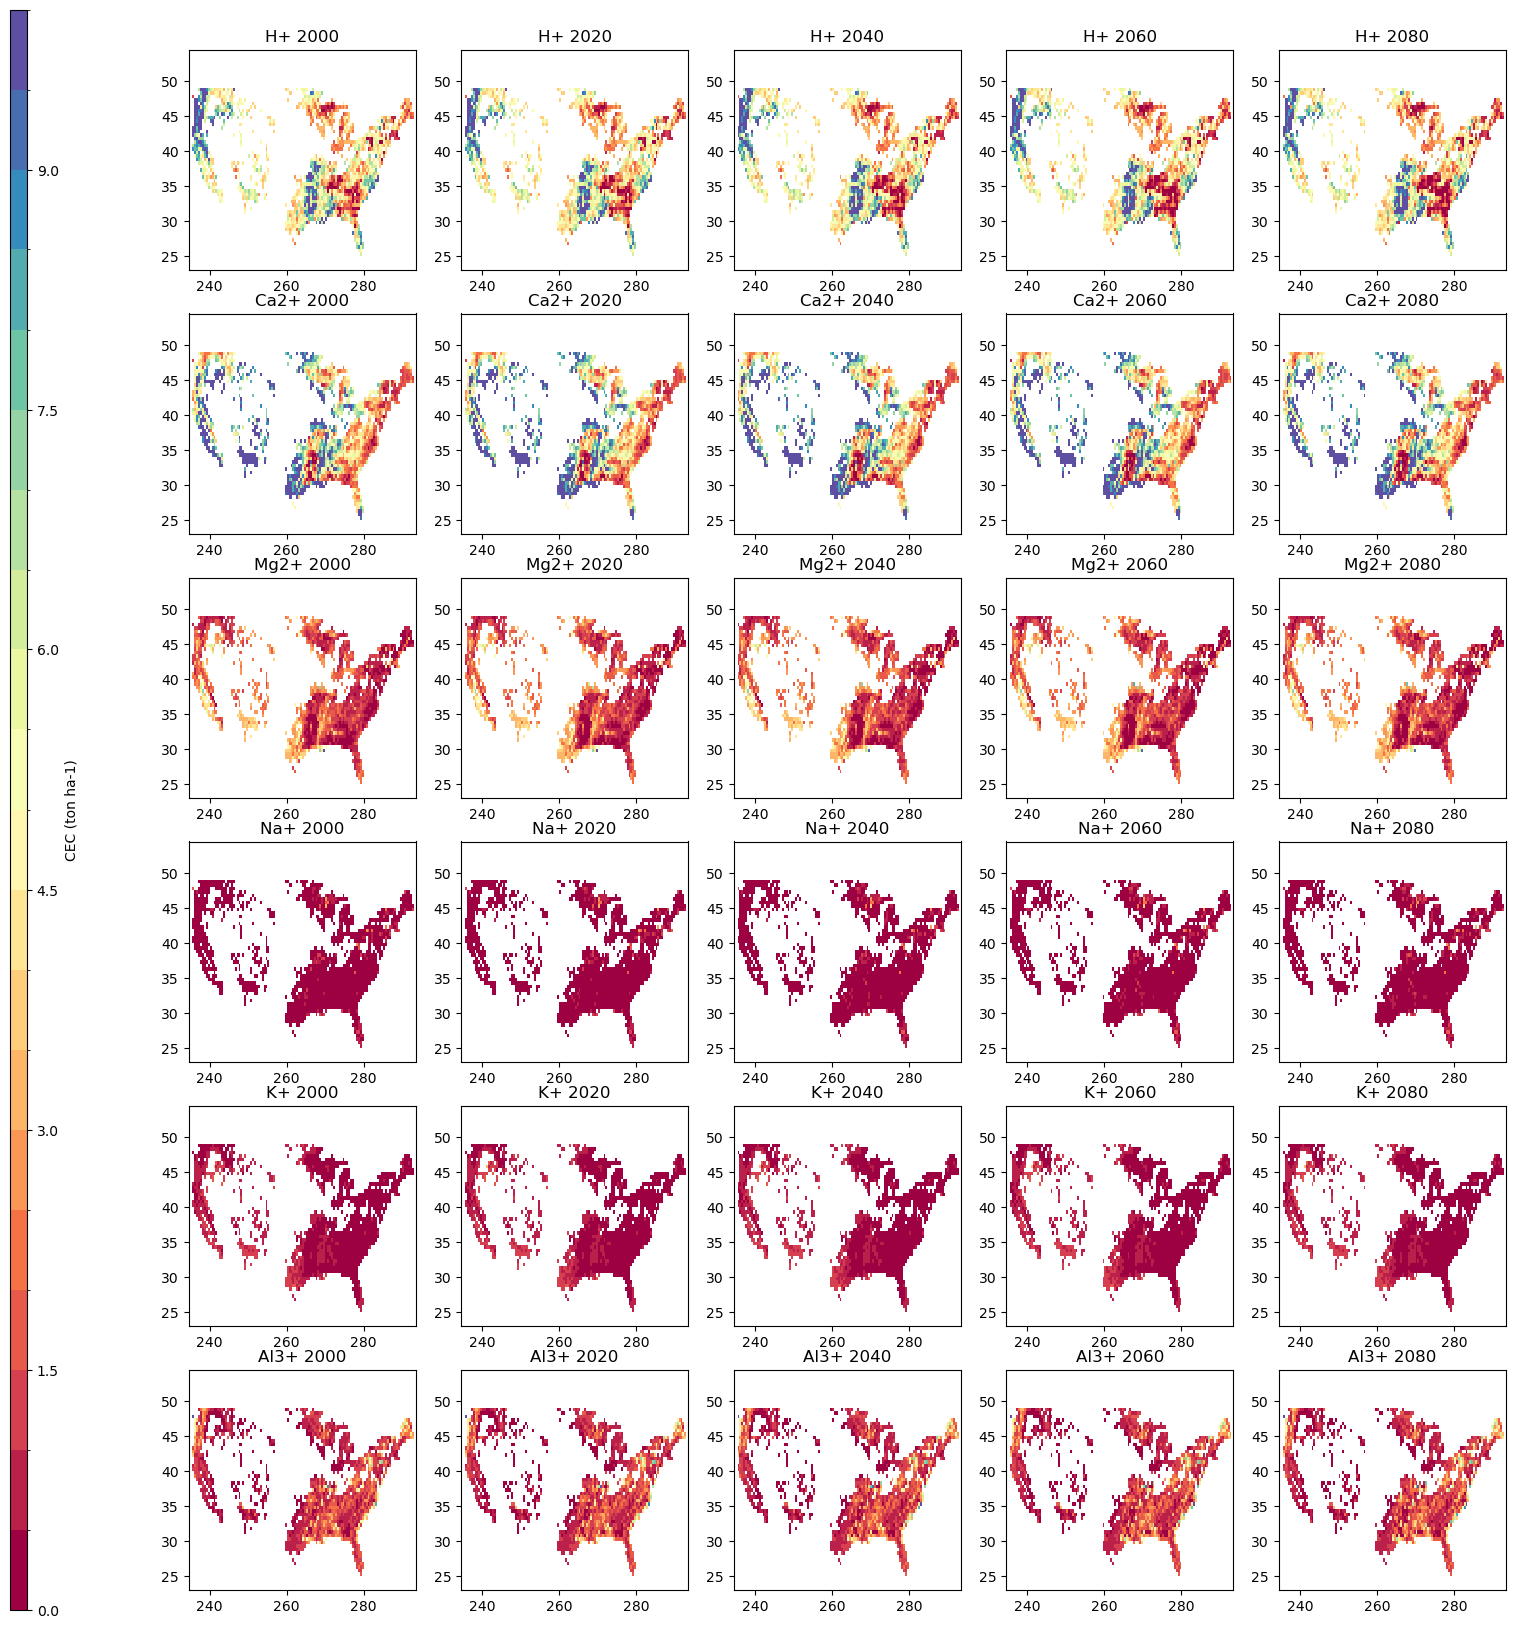

In [59]:
fig, axes = plt.subplots(6, 5, figsize = [17, 20])
for i, year in enumerate(np.arange(start_year, end_year, 20)):
    hr = xr.open_dataset(
        os.path.join(path_root, f'run', 
                    f'{prefix}_conus_ICB20TRCNPRDCTCBC_erw_pft1.elm.h1.{year}-01-01-00000.nc')
    )

    norm = BoundaryNorm(boundaries = np.linspace(0, 10, 21), ncolors=256)

    ax = axes.flat[i]
    proton_id = np.sum(hr['cec_proton_vr'][0,:10,:,:].values * 100 / \
                       hr['bd_col'][0,:10,:,:].values * zsoi[:10].reshape(-1,1,1), 
                       axis = 0) / np.sum(zsoi[:10])
    cf = ax.pcolormesh(
        hr['lon'], hr['lat'], proton_id,
        cmap = 'Spectral', norm = norm
    )
    ax.set_title(f'H+ {year}')

    for icat in range(1, 6):
        ax = axes.flat[icat*5 + i]

        cec_id = np.sum(hr[f'cec_cation_vr_{icat}'][0, :10, :].values * 100 * \
                        cation_valences[icat-1] / cation_masses[icat-1] / \
                        hr['bd_col'][0,:10,:,:].values * zsoi[:10].reshape(-1,1,1),
                        axis = 0) / np.sum(zsoi[:10])

        cf = ax.pcolormesh(hr['lon'], hr['lat'], cec_id, cmap = 'Spectral', norm = norm)

        ax.set_title(f'{cation_names[icat-1]} {year}')

    hr.close()

cax = fig.add_axes([0.02, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, label = 'CEC (ton ha-1)')
plt.savefig(os.path.join(path_out, f'cec_ensemble{id}.png'), dpi = 600., bbox_inches = 'tight')
#plt.close(fig)